In [1]:
# 环境与依赖导入
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

# 解决中文显示问题
matplotlib.rcParams["font.family"] = "SimHei"
matplotlib.rcParams["axes.unicode_minus"] = False

# 文件路径配置
INPUT_FILE = "../../2.预处理/镖人_风起大漠_cleaned.csv"
FONT_PATH  = "C:/Windows/Fonts/simhei.ttf"
RANDOM_STATE = 42

# 三类颜色方案
TYPE_META = {
    1:  {"label": "好评", "color": "#2ECC71", "cmap": "Greens"},
    0:  {"label": "中评", "color": "#F39C12", "cmap": "Oranges"},
    -1: {"label": "差评", "color": "#E74C3C", "cmap": "Reds"},
}

type_order = [1, 0, -1]
type_labels = [TYPE_META[t]["label"] for t in type_order]
type_colors_list = [TYPE_META[t]["color"] for t in type_order]

读取数据，隔离拆分好/差评

In [2]:
df = pd.read_csv(INPUT_FILE, encoding="utf-8-sig")
df["tokens"] = df["tokens"].fillna("")

# 将好评和差评拆分开来，分别建立 DataFrame
df_good = df[df["comment_type"] == 1].copy()
df_bad = df[df["comment_type"] == -1].copy()

print(f"总数据量：{len(df)}")
print(f"好评数据量：{len(df_good)} 条")
print(f"差评数据量：{len(df_bad)} 条")


总数据量：1194
好评数据量：400 条
差评数据量：395 条


## 1. 三类评论词云图

### 1.1 独立词云

分别统计好/中/差三类评论的词频，使用 `generate_from_frequencies` 生成词云，
横向 1×3 排列，配色与情感色调一致（绿 / 橙 / 红）。

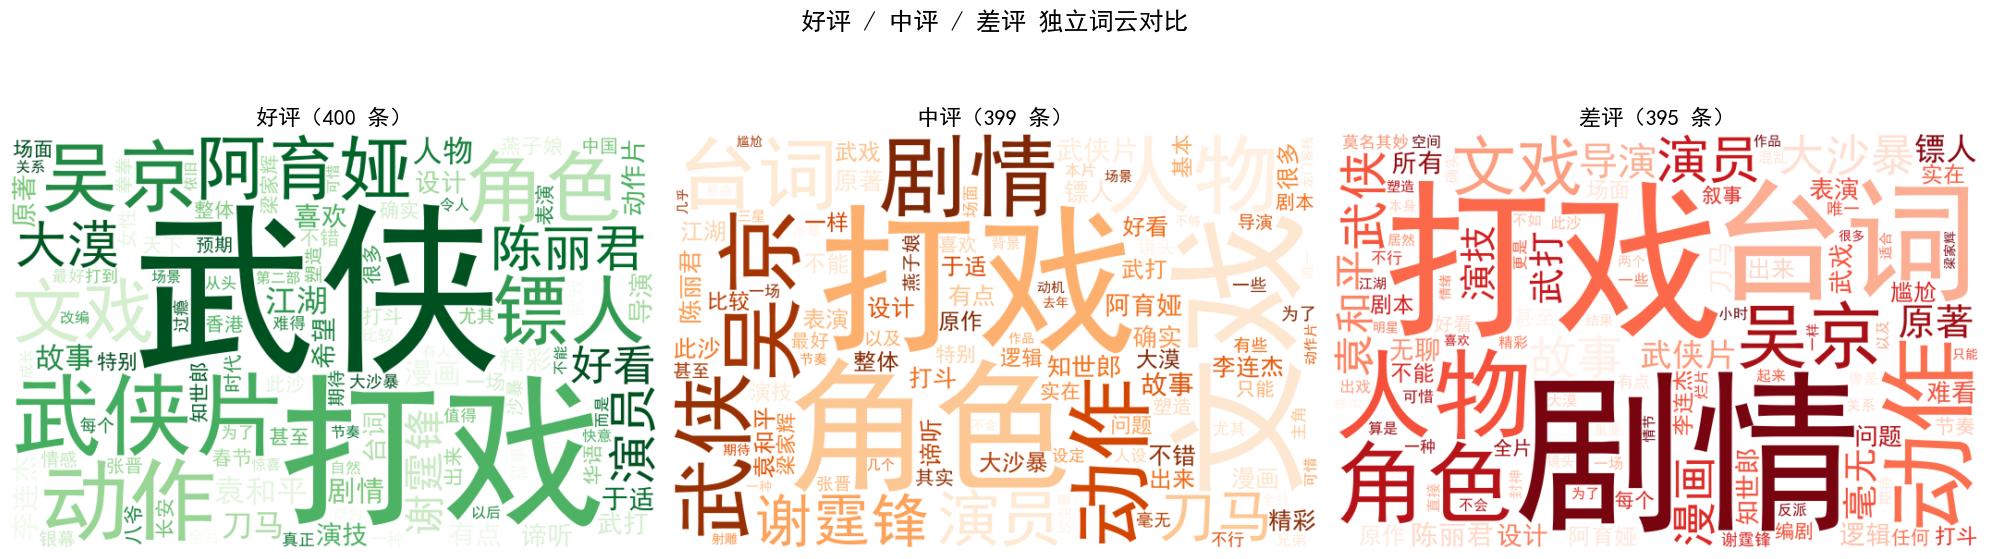

✅ 已保存：词云_三类对比.png


In [3]:
def get_word_freq(token_series):
    """统计分词结果中的词频"""
    all_words = " ".join(token_series).split()
    return Counter(all_words)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, t in enumerate(type_order):
    meta = TYPE_META[t]
    subset = df[df["comment_type"] == t]
    freq = get_word_freq(subset["tokens"])
    wc = WordCloud(
        font_path=FONT_PATH,
        width=700, height=450,
        background_color="white",
        max_words=100,
        colormap=meta["cmap"],
    ).generate_from_frequencies(freq)
    axes[idx].imshow(wc, interpolation="bilinear")
    axes[idx].set_title(f'{meta["label"]}（{len(subset)} 条）',
                        fontsize=16, fontweight="bold")
    axes[idx].axis("off")

plt.suptitle("好评 / 中评 / 差评 独立词云对比", fontsize=18, y=1.02)
plt.tight_layout()
plt.savefig("词云_三类对比.png", dpi=150, bbox_inches="tight")
plt.show()
print("\u2705 已保存：词云_三类对比.png")

### 1.2 特征词词云（去除共有高频词）

对每类评论，用 TF-IDF 提取该类区分度最高的词，
只保留「本类独有」的表达，过滤掉三类共享的通用词。

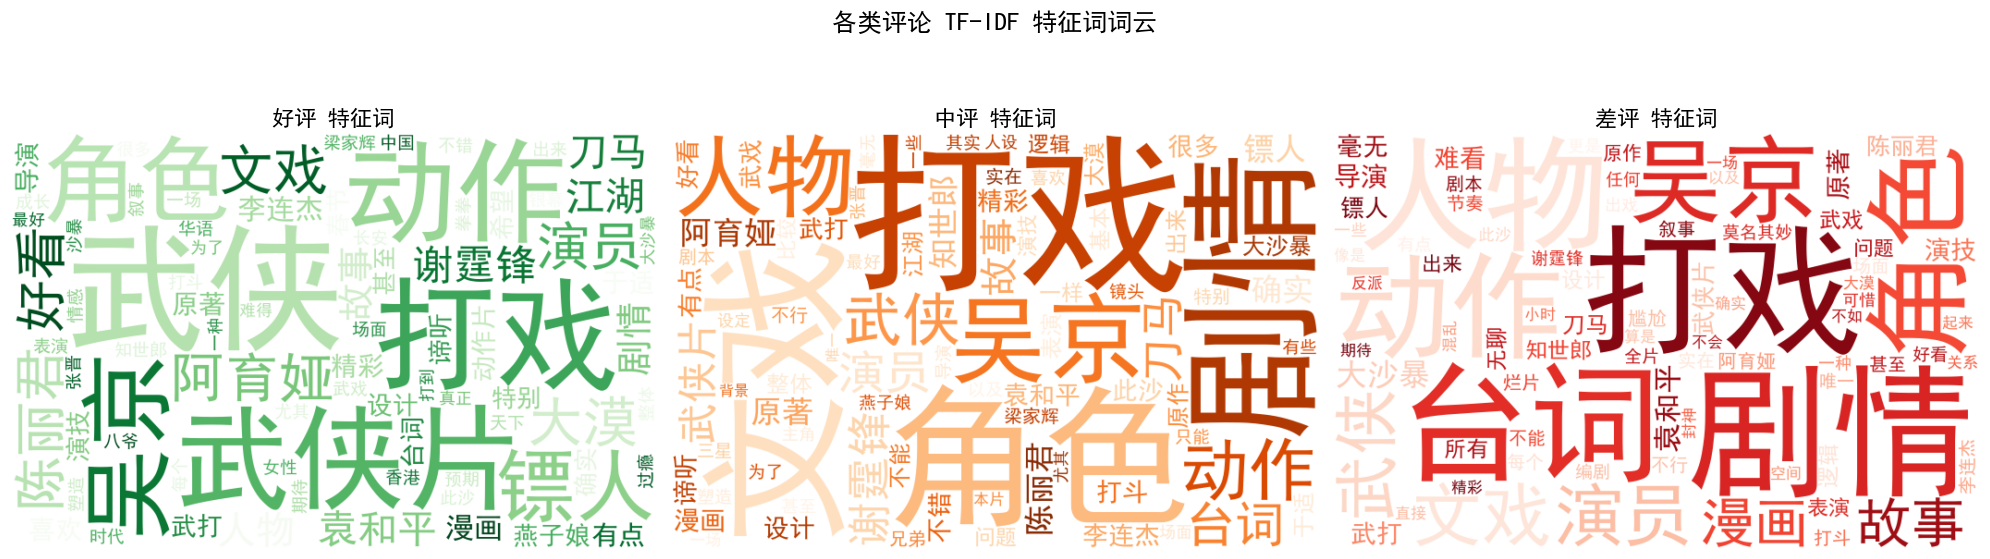

✅ 已保存：词云_特征词对比.png


In [4]:
# 将三类评论各自合并为一篇伪文档；相当于三篇文章
pseudo_docs = []
for t in type_order:
    merged = " ".join(df[df["comment_type"] == t]["tokens"])
    pseudo_docs.append(merged)

tfidf_class = TfidfVectorizer(max_features=500)
X_class = tfidf_class.fit_transform(pseudo_docs)
class_features = tfidf_class.get_feature_names_out()

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, t in enumerate(type_order):
    meta = TYPE_META[t]
    row = X_class[idx].toarray().flatten()
    top_idx = row.argsort()[::-1][:80]
    word_weights = {class_features[j]: row[j] for j in top_idx if row[j] > 0}

    wc = WordCloud(
        font_path=FONT_PATH,
        width=700, height=450,
        background_color="white",
        max_words=80,
        colormap=meta["cmap"],
    ).generate_from_frequencies(word_weights)
    axes[idx].imshow(wc, interpolation="bilinear")
    axes[idx].set_title(f'{meta["label"]} 特征词',
                        fontsize=16, fontweight="bold")
    axes[idx].axis("off")

plt.suptitle("各类评论 TF-IDF 特征词词云", fontsize=18, y=1.02)
plt.tight_layout()
plt.savefig("词云_特征词对比.png", dpi=150, bbox_inches="tight")
plt.show()
print("\u2705 已保存：词云_特征词对比.png")

对每类评论取 TF-IDF 权重最高的 Top 15 词，横向柱状图展示。

这些词是最能代表该类评论、区别于其他类的表达。

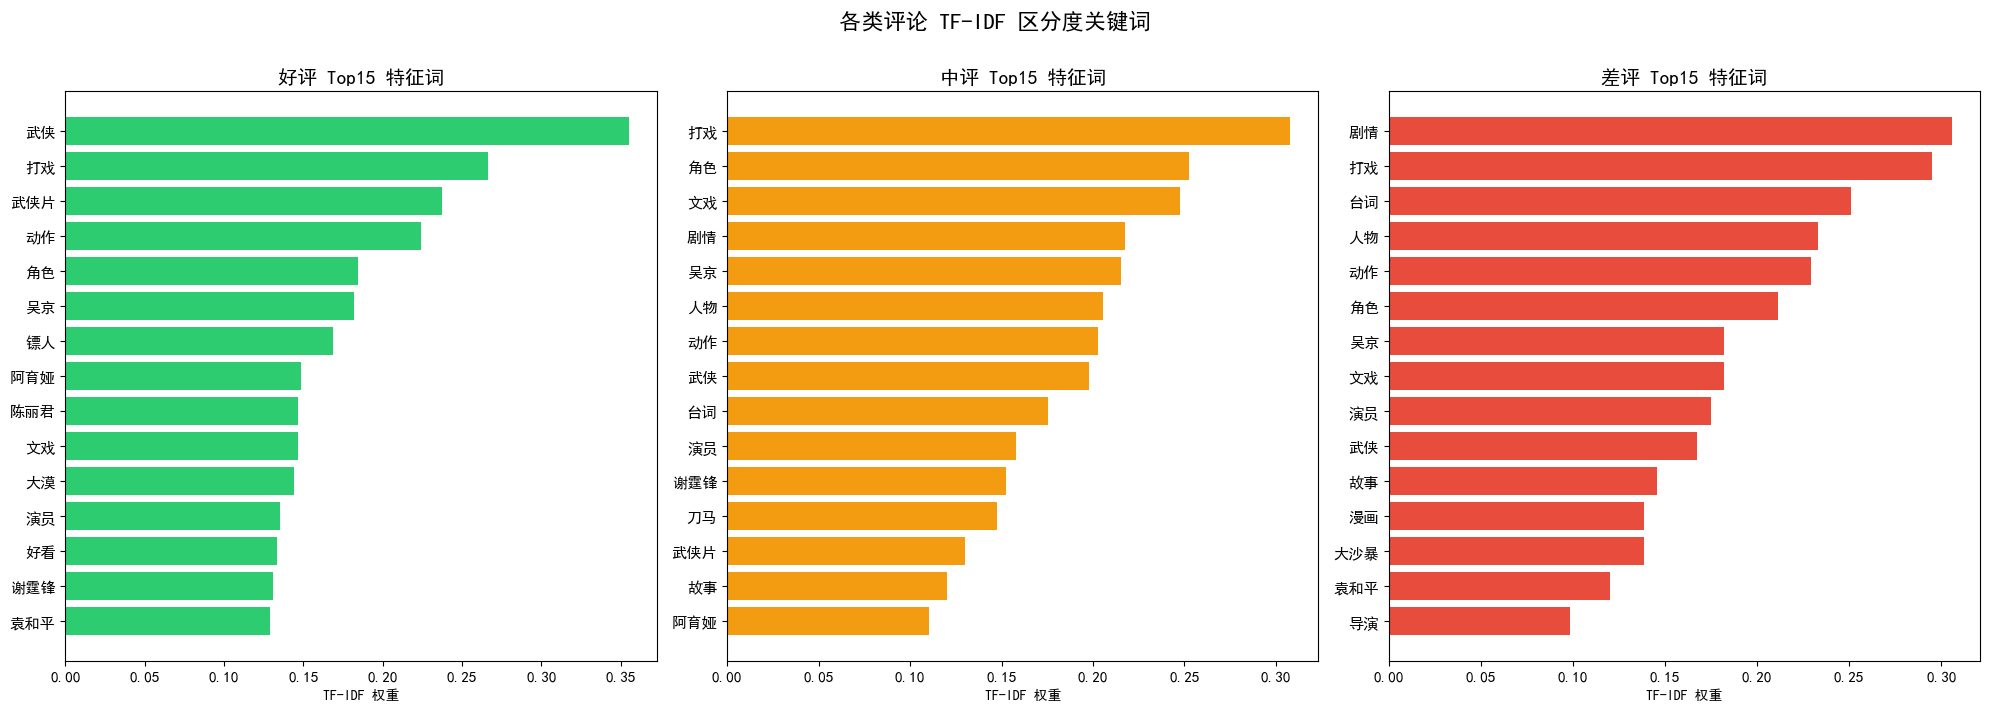

✅ 已保存：TFIDF_区分度关键词.png


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for idx, t in enumerate(type_order):
    meta = TYPE_META[t]
    row = X_class[idx].toarray().flatten()
    top_idx = row.argsort()[::-1][:15]
    words = [class_features[j] for j in top_idx]
    weights = [row[j] for j in top_idx]

    axes[idx].barh(words[::-1], weights[::-1], color=meta["color"])
    axes[idx].set_title(f'{meta["label"]} Top15 特征词',
                        fontsize=14, fontweight="bold")
    axes[idx].set_xlabel("TF-IDF 权重")
    axes[idx].tick_params(labelsize=11)

plt.suptitle("各类评论 TF-IDF 区分度关键词", fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig("TFIDF_区分度关键词.png", dpi=150, bbox_inches="tight")
plt.show()
print("\u2705 已保存：TFIDF_区分度关键词.png")

## 2. 高频词对比柱状图

取全局 Top 20 高频词，展示同一个词在好/中/差三类中的频率差异。

纵轴已归一化为「每400条评论中的出现次数」，消除各类样本量差异的影响。

可以发现：对武侠、动作好评较多，对台词剧情差评较多。

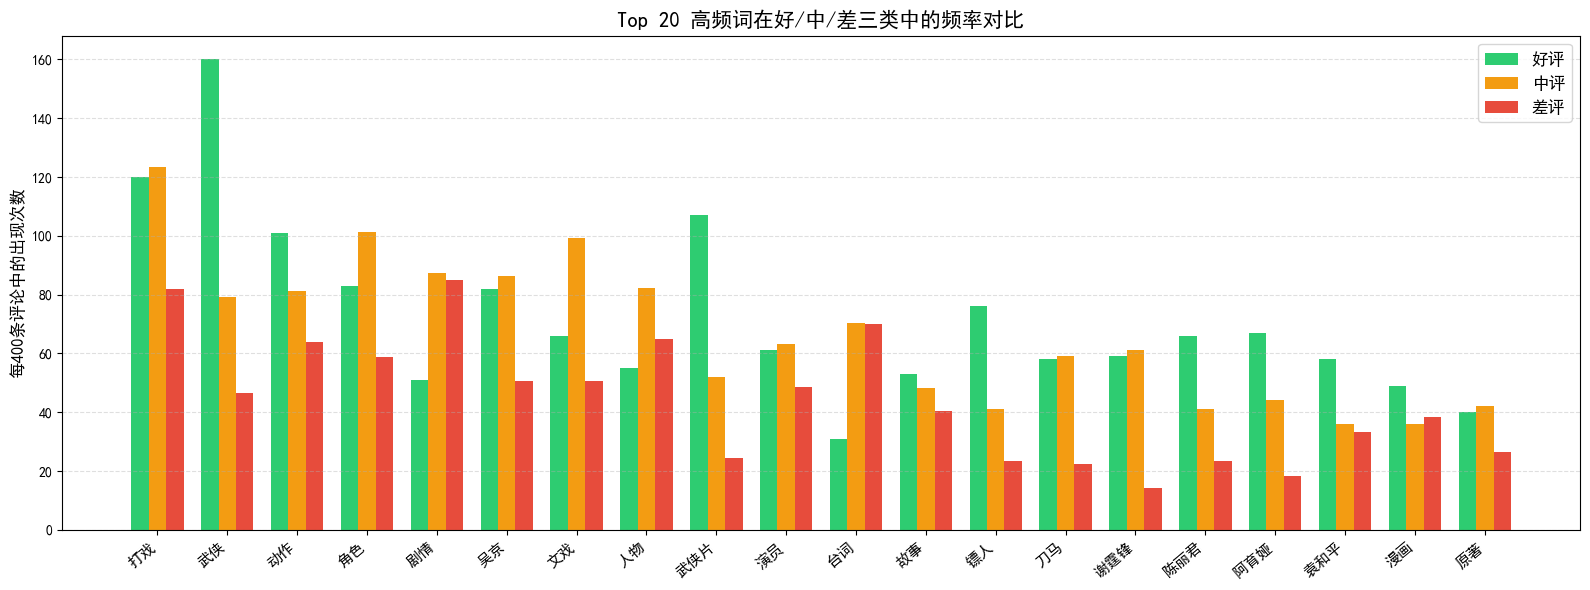

✅ 已保存：高频词_三类对比.png


In [6]:
freq_by_type = {}
for t in type_order:
    freq_by_type[t] = get_word_freq(df[df["comment_type"] == t]["tokens"])

global_freq = get_word_freq(df["tokens"])
top20_words = [w for w, _ in global_freq.most_common(20)]

x = np.arange(len(top20_words))
width = 0.25

fig, ax = plt.subplots(figsize=(16, 6))
for i, t in enumerate(type_order):
    meta = TYPE_META[t]
    n_docs = (df["comment_type"] == t).sum()
    rates = [freq_by_type[t].get(w, 0) / n_docs * 400 for w in top20_words]
    ax.bar(x + i * width, rates, width, label=meta["label"], color=meta["color"])

ax.set_xticks(x + width)
ax.set_xticklabels(top20_words, fontsize=11, rotation=40, ha="right")
ax.set_ylabel("每400条评论中的出现次数", fontsize=12)
ax.set_title("Top 20 高频词在好/中/差三类中的频率对比", fontsize=15)
ax.legend(fontsize=12)
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("高频词_三类对比.png", dpi=150)
plt.show()
print("\u2705 已保存：高频词_三类对比.png")

### 3. LDA 主题挖掘（分别对好评和差评）

In [7]:
def discover_topics(texts, n_topics=3, n_top_words=10):
    """
    针对输入的文本列表，训练 LDA 主题模型并提取高频特征词
    """
    # 1. 文本向量化 (使用词频，忽略极低频和极高频词)
    tf_vectorizer = CountVectorizer(max_features=800, min_df=3, max_df=0.85)
    tf = tf_vectorizer.fit_transform(texts)
    
    # 2. 训练 LDA 模型
    lda = LatentDirichletAllocation(
        n_components=n_topics, 
        max_iter=20,
        learning_method='online',
        random_state=RANDOM_STATE
    )
    lda.fit(tf)
    
    # 3. 提取并打印每个主题的核心词
    feature_names = tf_vectorizer.get_feature_names_out()
    topics_words = []
    
    print(f"--- 成功提取 {n_topics} 个潜在主题 ---")
    for topic_idx, topic in enumerate(lda.components_):
        top_features_ind = topic.argsort()[:-n_top_words - 1:-1]
        top_features = [feature_names[i] for i in top_features_ind]
        topics_words.append(top_features)
        print(f"主题 #{topic_idx + 1}: {' | '.join(top_features)}")
        
    return tf_vectorizer, tf, lda, topics_words


挖掘好评/差评主题 (好评到底在夸什么？差评到底在骂什么？)

它的长板（动作与选角）极度成功：袁和平的动作设计、大漠的美术还原，以及“吴京+李连杰+此沙+陈丽君”这种跨越圈层和代际的神仙选角，牢牢锁住了武侠粉、IP粉和演员粉丝的基本盘。

它的短板（编剧与台词）极其致命：电影在叙事逻辑、台词本土化和文戏节奏上全面溃败，导致非IP粉丝的普通观众觉得“无聊”、“平庸”，甚至觉得为了打而打，过于“暴力”。

In [8]:
print("【好评主题分析】")
# 根据你的好评量，假设提取 3 个主题，每个主题看前 12 个词
good_tf_vectorizer, good_tf, good_lda, good_topics = discover_topics(
    df_good["tokens"], n_topics=3, n_top_words=12
)

print("\n【差评主题分析】")
# 同样提取 3 个主题
bad_tf_vectorizer, bad_tf, bad_lda, bad_topics = discover_topics(
    df_bad["tokens"], n_topics=3, n_top_words=12
)


【好评主题分析】
--- 成功提取 3 个潜在主题 ---
主题 #1: 武侠 | 镖人 | 武侠片 | 袁和平 | 动作 | 演员 | 打戏 | 华语 | 李连杰 | 喜欢 | 漫画 | 吴京
主题 #2: 此沙 | 文戏 | 陈丽君 | 来看 | 好看 | 谢霆锋 | 封神 | 故事 | 方面 | 背景 | 打戏 | 演员
主题 #3: 打戏 | 天下 | 角色 | 武侠 | 阿育娅 | 刀马 | 吴京 | 大漠 | 剧情 | 动作 | 陈丽君 | 李连杰

【差评主题分析】
--- 成功提取 3 个潜在主题 ---
主题 #1: 台词 | 故事 | 大沙暴 | 角色 | 漫画 | 打戏 | 人物 | 知世郎 | 原著 | 演员 | 难看 | 袁和平
主题 #2: 剧情 | 吴京 | 逻辑 | 打戏 | 无聊 | 武戏 | 文戏 | 直接 | 结果 | 演技 | 人物 | 过去
主题 #3: 暴力 | 武侠 | 设计 | 叙事 | 袁和平 | 烂片 | 居然 | 毫无 | 打斗 | 平庸 | 镖人 | 个人


使用 pyLDAvis 进行交互式可视化 (以好评为例)

In [ ]:
import pyLDAvis
import pyLDAvis.lda_model

pyLDAvis.enable_notebook()

# 可视化好评的主题分布
good_vis = pyLDAvis.lda_model.prepare(good_lda, good_tf, good_tf_vectorizer)
display(good_vis)

# 可以复制这一段代码，将 good 替换为 bad，单独再画一个差评的交互图。


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
2     -0.086805  0.116977       1        1  44.912241
0     -0.100323 -0.111476       2        1  44.715204
1      0.187128 -0.005501       3        1  10.372555, topic_info=    Term       Freq       Total Category  logprob  loglift
758  陈丽君  52.000000   52.000000  Default  30.0000  30.0000
275   天下  62.000000   62.000000  Default  29.0000  29.0000
748   镖人  96.000000   96.000000  Default  28.0000  28.0000
510   演员  61.000000   61.000000  Default  27.0000  27.0000
425   文戏  63.000000   63.000000  Default  26.0000  26.0000
..   ...        ...         ...      ...      ...      ...
404   打戏   9.804987  120.623028   Topic3  -4.3911  -0.2438
97    于适   7.358497   33.291048   Topic3  -4.6781   0.7566
674   诚意   5.734368   11.540091   Topic3  -4.9275   1.5667
712   这些   5.687715   13.009232   Topic3  -4.9357   1.4387
234   吴京   6.809544   75.801468   Topic3  -4.7556  -0.1438

[201 rows x 6 columns], token_table=      Topic      Freq Term
term                      
3         2  0.942942   81
4         2  0.965002   90
5         2  0.943377   ai
6         1  0.168462  bug
6         3  0.842312  bug
...     ...       ...  ...
770       1  0.765004   预期
770       2  0.225001   预期
781       2  0.929865   香港
792       2  0.991538  麦克斯
796       2  0.942952  黄飞鸿

[265 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[3, 1, 2])

### 4. 结合 votes_count 的平方根加权关键词分析

好评：武侠: 1182 / 武侠片: 1172  角色好：吴京: 668 / 陈丽君: 548 / 阿育娅: 484

差评：剧情: 563 / 台词: 491；大沙暴: 253（特效不好）；封神：253（“去年的封神，今年的镖人”）

“打戏”、“文戏”、“角色”、“演员” 这几个词同时出现在好评和差评，褒贬不一。

In [10]:
def get_weighted_top_words(df, top_n=15):
    """计算按获赞数加权后的高频词"""
    weighted_freq = Counter()
    
    for _, row in df.iterrows():
        # 基础权重设为 1，加上点赞数
        weight = int(row.get('votes_count', 0)) + 1 
        tokens = str(row['tokens']).split()
        for word in tokens:
            weighted_freq[word] += weight ** 0.5
            
    return weighted_freq.most_common(top_n)

print("【最具大众共鸣的好评词汇（含点赞加权）】")
for word, score in get_weighted_top_words(df_good, 12):
    print(f"{word}: {score:.2f} 声量")

print("\n【最具大众共鸣的差评词汇（含点赞加权）】")
for word, score in get_weighted_top_words(df_bad, 12):
    print(f"{word}: {score:.2f} 声量")


【最具大众共鸣的好评词汇（含点赞加权）】
武侠: 1182.93 声量
武侠片: 1172.50 声量
打戏: 840.86 声量
动作: 675.17 声量
吴京: 668.20 声量
角色: 638.35 声量
文戏: 621.19 声量
镖人: 601.53 声量
陈丽君: 548.61 声量
演员: 536.45 声量
阿育娅: 484.06 声量
人物: 476.17 声量

【最具大众共鸣的差评词汇（含点赞加权）】
剧情: 563.17 声量
台词: 491.63 声量
打戏: 367.67 声量
角色: 367.01 声量
动作: 343.06 声量
人物: 308.47 声量
演员: 291.41 声量
文戏: 259.69 声量
武侠: 256.93 声量
镖人: 256.67 声量
封神: 253.54 声量
大沙暴: 253.27 声量
